In [22]:
import numpy as np
from scipy.integrate import solve_ivp, odeint
import matplotlib.pyplot as plt
import pandas as pd

### Exercice 1a)

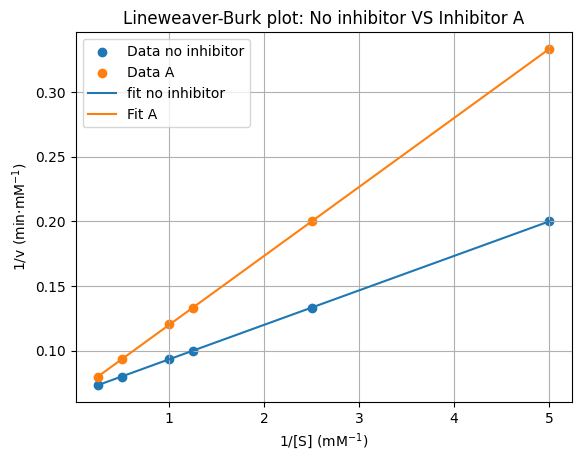

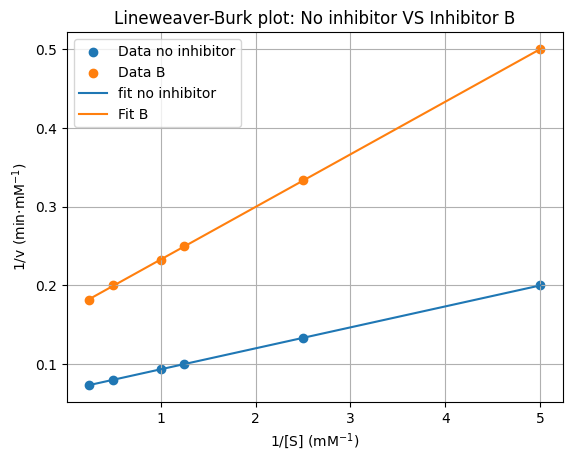

In [ ]:
#Given data
S = np.array([0.2, 0.4, 0.8, 1.0, 2.0, 4.0]) #[mM]
v_noI = np.array([5.0, 7.5, 10.0, 10.7, 12.5, 13.6]) #[mM/min]
v_A = np.array([3.0, 5.0, 7.5, 8.3, 10.7, 12.5]) #[mM/min]
v_B = np.array([2.0, 3.0, 4.0, 4.3, 5.0, 5.5]) #[mM/min]

#Lineweaver-Burk plot : 1/v vs 1/[S]
S_inverse = 1/S
v_noI_inverse = 1/v_noI
v_A_inverse = 1/v_A
v_B_inverse = 1/v_B

#Finding constants in Lineweaver-Burk plot
slope_noI, intercept_noI = np.polyfit(S_inverse, v_noI_inverse, 1)
Vmax_noI = 1/intercept_noI
Km_noI = slope_noI * Vmax_noI

slope_A, intercept_A = np.polyfit(S_inverse, v_A_inverse, 1)
Vmax_A = 1/intercept_A
Km_A = slope_A * Vmax_A

slope_B, intercept_B = np.polyfit(S_inverse, v_B_inverse, 1)
Vmax_B = 1/intercept_B
Km_B = slope_B * Vmax_B

#Plotting the graphs
x_fit = np.linspace(np.min(S_inverse), np.max(S_inverse), 100)

plt.scatter(S_inverse, v_noI_inverse, label="Data no inhibitor")
plt.scatter(S_inverse, v_A_inverse, label="Data A")
plt.plot(x_fit, slope_noI * x_fit + intercept_noI, label="fit no inhibitor")
plt.plot(x_fit, slope_A * x_fit + intercept_A, label="Fit A")
plt.xlabel("1/[S] (mM$^{-1}$)")
plt.ylabel("1/v (min·mM$^{-1}$)")
plt.title("Lineweaver-Burk plot: No inhibitor VS Inhibitor A")
plt.grid(True)
plt.legend()
plt.show()

plt.scatter(S_inverse, v_noI_inverse, label="Data no inhibitor")
plt.scatter(S_inverse, v_B_inverse, label="Data B")
plt.plot(x_fit, slope_noI * x_fit + intercept_noI, label="fit no inhibitor")
plt.plot(x_fit, slope_B * x_fit + intercept_B, label="Fit B")
plt.xlabel("1/[S] (mM$^{-1}$)")
plt.ylabel("1/v (min·mM$^{-1}$)")
plt.title("Lineweaver-Burk plot: No inhibitor VS Inhibitor B")
plt.grid(True)
plt.legend()
plt.show()

### Exercice 1b)

In [ ]:
#Tabulating Km and Vmax values
data = {
    "Condition": ["No inhibitor", "Inhibitor A", "Inhibitor B"],
    "Vmax (mM/min)": [Vmax_noI, Vmax_A, Vmax_B],
    "Km (mM)": [Km_noI, Km_A, Km_B]
}

table = pd.DataFrame(data)
table = table.round(3)
table

,Condition,Vmax (mM/min),Km (mM)
0,No inhibitor,14.978,0.399
1,Inhibitor A,14.964,0.798
2,Inhibitor B,6.025,0.403


### Exercice 1d)

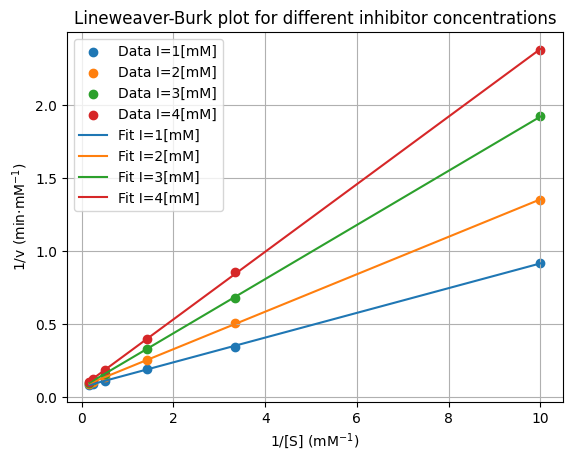

a= 0.05 [min/mM]
b= 0.033 [min]
Ki= 0.665 [mM]


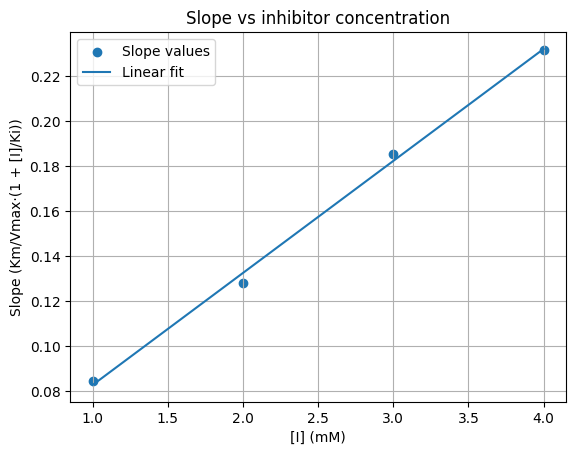

In [ ]:
#Data
S_d = np.array([0.1, 0.3, 0.7, 2.0, 4.0, 6.0]) #[mM]
I1 = 1 #[mM]
I2 = 2 #[mM]
I3 = 3 #[mM]
I4 = 4 #[mM]
v1 = np.array([1.09, 2.89, 5.24, 8.85, 10.89, 12.11]) #[mM/min]
v2 = np.array([0.74, 1.96, 3.89, 7.40, 9.82, 11.36]) #[mM/min]
v3 = np.array([0.52, 1.47, 3.01, 6.31, 8.76, 10.02]) #[mM/min]
v4 = np.array([0.42, 1.17, 2.51, 5.43, 8.07, 9.37]) #[mM/min]

#Lineweaver_Burk plot: 1/v vs 1/[S]
S_di = 1/S_d
v1_i = 1/v1
v2_i = 1/v2
v3_i = 1/v3
v4_i = 1/v4

#Finding slopes and intercepts of Lineweaver-Burk plot
slope_1, intercept_1 = np.polyfit(S_di, v1_i, 1)
slope_2, intercept_2 = np.polyfit(S_di, v2_i, 1)
slope_3, intercept_3 = np.polyfit(S_di, v3_i, 1)
slope_4, intercept_4 = np.polyfit(S_di, v4_i, 1)

#plotting the graphs
xfit = np.linspace(np.min(S_di), np.max(S_di), 100)

plt.scatter(S_di, v1_i, label="Data I=1[mM]")
plt.scatter(S_di, v2_i, label="Data I=2[mM]")
plt.scatter(S_di, v3_i, label="Data I=3[mM]")
plt.scatter(S_di, v4_i, label="Data I=4[mM]")
plt.plot(xfit, slope_1 * xfit + intercept_1, label="Fit I=1[mM]")
plt.plot(xfit, slope_2 * xfit + intercept_2, label="Fit I=2[mM]")
plt.plot(xfit, slope_3 * xfit + intercept_3, label="Fit I=3[mM]")
plt.plot(xfit, slope_4 * xfit + intercept_4, label="Fit I=4[mM]")
plt.xlabel("1/[S] (mM$^{-1}$)")
plt.ylabel("1/v (min·mM$^{-1}$)")
plt.title("Lineweaver-Burk plot for different inhibitor concentrations")
plt.grid(True)
plt.legend()
plt.show()

#Finding Ki for different I concentrations
I_values = np.array([I1, I2, I3, I4])
slopes = np.array([slope_1, slope_2, slope_3, slope_4])

a, b = np.polyfit(I_values, slopes, 1)
Ki = b/a

print("a=", a.round(3), "[min/mM]")
print("b=", b.round(3), "[min]")
print("Ki=", Ki.round(3), "[mM]")

#Graph to see Ki
xI = np.linspace(np.min(I_values), np.max(I_values), 100)

plt.scatter(I_values, slopes, label="Slope values")
plt.plot(xI, a*xI + b, label="Linear fit")
plt.xlabel("[I] (mM)")
plt.ylabel("Slope (Km/Vmax·(1 + [I]/Ki))")
plt.title("Slope vs inhibitor concentration")
plt.grid(True)
plt.legend()
plt.show()